# Consumer Staples Competitive & Financial Analysis Engine

Python-based peer analysis of Procter & Gamble, Coca-Cola, PepsiCo, Colgate-Palmolive, and Mondelez.

The project evaluates financial performance, profitability, capital efficiency, leverage, relative valuation, and competitive positioning using FY2025 financial data and market data as of September 4, 2026.

**Objective:** Identify relative financial strengths, weaknesses, valuation differences, and investment-relevant positioning across major consumer staples companies.

## 1. Setup & Data Collection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

companies = {
    "Procter & Gamble": "PG",
    "Coca-Cola": "KO",
    "PepsiCo": "PEP",
    "Colgate-Palmolive": "CL",
    "Mondelez": "MDLZ"
}

tickers = list(companies.values())

print("Companies:", tickers)

Companies: ['PG', 'KO', 'PEP', 'CL', 'MDLZ']


In [ ]:
prices = yf.download(
    tickers,
    start="2021-01-01",
    end="2026-01-01",
    auto_adjust=False
)

prices.head()

[*********************100%***********************]  5 of 5 completed


Price       Adj Close                                                \
Ticker             CL         KO       MDLZ         PEP          PG   
Date                                                                  
2021-01-04  73.625206  44.792774  50.213665  119.999947  118.965569   
2021-01-05  73.791061  44.300362  50.265697  120.357536  119.725151   
2021-01-06  71.809242  42.891037  50.170338  118.885345  120.985428   
2021-01-07  71.416351  42.415596  50.074970  118.502731  119.854660   
2021-01-08  71.896523  43.366482  50.447746  119.925034  119.802841   

Price           Close                                                ...  \
Ticker             CL         KO       MDLZ         PEP          PG  ...   
Date                                                                 ...   
2021-01-04  84.330002  52.759998  57.919998  144.270004  137.820007  ...   
2021-01-05  84.519997  52.180000  57.980000  144.699997  138.699997  ...   
2021-01-06  82.250000  50.520000  57.869999  142.929993  140.160004  ...   
2021-01-07  81.800003  49.959999  57.759998  142.470001  138.850006  ...   
2021-01-08  82.349998  51.080002  58.189999  144.179993  138.789993  ...   

Price            Open                                                 Volume  \
Ticker             CL         KO       MDLZ         PEP          PG       CL   
Date                                                                           
2021-01-04  84.779999  54.270000  58.490002  147.009995  139.660004  3506000   
2021-01-05  84.330002  52.330002  57.889999  144.070007  137.990005  2559300   
2021-01-06  84.160004  51.970001  57.990002  141.669998  138.770004  9053900   
2021-01-07  81.910004  50.090000  57.720001  142.809998  139.750000  5061000   
2021-01-08  82.089996  50.029999  57.369999  142.470001  138.470001  5569300   

Price                                             
Ticker            KO     MDLZ      PEP        PG  
Date                                              
2021-01-04  25611100  9187200  7486900   8330900  
2021-01-05  20323800  5421900  4126000   6856400  
2021-01-06  38724500  7663200  4843300  10578000  
2021-01-07  53225700  8589100  4473200   7355400  
2021-01-08  29674000  6642700  4312000   7448500  

[5 rows x 30 columns]

In [ ]:
financials = {}

for ticker in tickers:
    stock = yf.Ticker(ticker)

    financials[ticker] = {
        "income": stock.financials,
        "balance_sheet": stock.balance_sheet,
        "cash_flow": stock.cashflow
    }

print("Financial statements downloaded.")

Financial statements downloaded.


In [ ]:
for ticker in tickers:
    print("\n================", ticker, "================")

    print("\nINCOME STATEMENT")
    print(financials[ticker]["income"].index.tolist())

    print("\nBALANCE SHEET")
    print(financials[ticker]["balance_sheet"].index.tolist())

    print("\nCASH FLOW")
    print(financials[ticker]["cash_flow"].index.tolist())


================ PG ================

INCOME STATEMENT
['Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Normalized EBITDA', 'Total Unusual Items', 'Total Unusual Items Excluding Goodwill', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA', 'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Total Expenses', 'Total Operating Income As Reported', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Average Dilution Earnings', 'Net Income Common Stockholders', 'Preferred Stock Dividends', 'Net Income', 'Minority Interests', 'Net Income Including Noncontrolling Interests', 'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income', 'Other Income Expense', 'Other Non Operating Income Expenses', 'Special Income Charges', 'Impairment Of Cap

In [ ]:
metrics = [
    "Total Revenue",
    "Gross Profit",
    "Operating Income",
    "Net Income",
    "Operating Cash Flow",
    "Capital Expenditure",
    "Total Assets",
    "Stockholders Equity",
    "Cash Cash Equivalents And Short Term Investments",
    "Total Debt"
]

for ticker in tickers:
    print(f"\n{ticker}")

    for statement_name, statement in financials[ticker].items():
        available = [x for x in metrics if x in statement.index]
        print(statement_name, ":", available)


PG
income : ['Total Revenue', 'Gross Profit', 'Operating Income', 'Net Income']
balance_sheet : ['Total Assets', 'Stockholders Equity', 'Cash Cash Equivalents And Short Term Investments', 'Total Debt']
cash_flow : ['Operating Cash Flow', 'Capital Expenditure']

KO
income : ['Total Revenue', 'Gross Profit', 'Operating Income', 'Net Income']
balance_sheet : ['Total Assets', 'Stockholders Equity', 'Cash Cash Equivalents And Short Term Investments', 'Total Debt']
cash_flow : ['Operating Cash Flow', 'Capital Expenditure']

PEP
income : ['Total Revenue', 'Gross Profit', 'Operating Income', 'Net Income']
balance_sheet : ['Total Assets', 'Stockholders Equity', 'Cash Cash Equivalents And Short Term Investments', 'Total Debt']
cash_flow : ['Operating Cash Flow', 'Capital Expenditure']

CL
income : ['Total Revenue', 'Gross Profit', 'Operating Income', 'Net Income']
balance_sheet : ['Total Assets', 'Stockholders Equity', 'Cash Cash Equivalents And Short Term Investments', 'Total Debt']
cash_flow 

In [ ]:
# ============================================
# CONSUMER STAPLES - FINANCIAL DATA PIPELINE
# ============================================

# Download financial statements
financials = {}

for ticker in tickers:
    stock = yf.Ticker(ticker)

    financials[ticker] = {
        "income": stock.financials,
        "balance_sheet": stock.balance_sheet,
        "cash_flow": stock.cashflow
    }

print("Financial statements downloaded.\n")


# ============================================
# CHECK AVAILABLE DATA
# ============================================

for ticker in tickers:
    print("=" * 50)
    print(ticker)
    print("=" * 50)

    print("\nIncome Statement:")
    print(financials[ticker]["income"].index.tolist())

    print("\nBalance Sheet:")
    print(financials[ticker]["balance_sheet"].index.tolist())

    print("\nCash Flow:")
    print(financials[ticker]["cash_flow"].index.tolist())

    print()

Financial statements downloaded.

PG

Income Statement:
['Tax Effect Of Unusual Items', 'Tax Rate For Calcs', 'Normalized EBITDA', 'Total Unusual Items', 'Total Unusual Items Excluding Goodwill', 'Net Income From Continuing Operation Net Minority Interest', 'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA', 'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income', 'Normalized Income', 'Net Income From Continuing And Discontinued Operation', 'Total Expenses', 'Total Operating Income As Reported', 'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS', 'Basic EPS', 'Diluted NI Availto Com Stockholders', 'Average Dilution Earnings', 'Net Income Common Stockholders', 'Preferred Stock Dividends', 'Net Income', 'Minority Interests', 'Net Income Including Noncontrolling Interests', 'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income', 'Other Income Expense', 'Other Non Operating Income Expenses', 'Special Income Charges', 'Impairment Of Cap

## 2. Financial Data Cleaning

In [ ]:
# ============================================
# BUILD CLEAN FINANCIAL DATASET
# ============================================

def get_value(statement, names):
    for name in names:
        if name in statement.index:
            return statement.loc[name]
    return pd.Series(index=statement.columns, dtype="float64")


rows = []

for company, ticker in companies.items():

    income = financials[ticker]["income"]
    balance = financials[ticker]["balance_sheet"]
    cashflow = financials[ticker]["cash_flow"]

    revenue = get_value(income, ["Total Revenue"])
    gross_profit = get_value(income, ["Gross Profit"])
    ebit = get_value(income, ["Operating Income"])
    net_income = get_value(income, ["Net Income"])
    ebitda = get_value(income, ["EBITDA", "Normalized EBITDA"])

    operating_cf = get_value(
        cashflow,
        ["Operating Cash Flow", "Total Cash From Operating Activities"]
    )

    capex = get_value(
        cashflow,
        ["Capital Expenditure", "Capital Expenditures"]
    )

    assets = get_value(balance, ["Total Assets"])

    equity = get_value(
        balance,
        ["Stockholders Equity", "Stockholders' Equity", "Common Stock Equity"]
    )

    cash = get_value(
        balance,
        [
            "Cash Cash Equivalents And Short Term Investments",
            "Cash And Cash Equivalents",
            "Cash Financial"
        ]
    )

    debt = get_value(
        balance,
        ["Total Debt", "Total Debt And Capital Lease Obligation"]
    )

    for date in income.columns:

        rows.append({
            "Company": company,
            "Ticker": ticker,
            "Year": pd.Timestamp(date).year,
            "Revenue": revenue.get(date, np.nan),
            "Gross_Profit": gross_profit.get(date, np.nan),
            "EBIT": ebit.get(date, np.nan),
            "EBITDA": ebitda.get(date, np.nan),
            "Net_Income": net_income.get(date, np.nan),
            "Operating_Cash_Flow": operating_cf.get(date, np.nan),
            "CapEx": capex.get(date, np.nan),
            "Total_Assets": assets.get(date, np.nan),
            "Total_Equity": equity.get(date, np.nan),
            "Cash": cash.get(date, np.nan),
            "Total_Debt": debt.get(date, np.nan)
        })


df = pd.DataFrame(rows)

# FCF = Operating Cash Flow - Capital Expenditure
df["FCF"] = df["Operating_Cash_Flow"] + df["CapEx"]

df = df.sort_values(["Company", "Year"], ascending=[True, False])

print("Dataset created!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.head(15)

Dataset created!
Rows: 24
Columns: 15


,Company,Ticker,Year,Revenue,Gross_Profit,EBIT,EBITDA,Net_Income,Operating_Cash_Flow,CapEx,Total_Assets,Total_Equity,Cash,Total_Debt,FCF
4,Coca-Cola,KO,2025,4.794100e+10,2.954400e+10,1.491100e+10,1.870200e+10,1.310700e+10,7.408000e+09,-2.112000e+09,1.048160e+11,3.216900e+10,1.580600e+10,4.549200e+10,5.296000e+09
5,Coca-Cola,KO,2024,4.706100e+10,2.873700e+10,1.402200e+10,1.581700e+10,1.063100e+10,6.805000e+09,-2.064000e+09,1.005490e+11,2.485600e+10,1.457100e+10,4.452200e+10,4.741000e+09
6,Coca-Cola,KO,2023,4.575400e+10,2.723400e+10,1.309800e+10,1.560700e+10,1.071400e+10,1.159900e+10,-1.852000e+09,9.770300e+10,2.594100e+10,1.366300e+10,4.206400e+10,9.747000e+09
7,Coca-Cola,KO,2022,4.300400e+10,2.500400e+10,1.204200e+10,1.382800e+10,9.542000e+09,1.101800e+10,-1.484000e+09,9.276300e+10,2.410500e+10,1.163100e+10,3.914900e+10,9.534000e+09
8,Coca-Cola,KO,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,Colgate-Palmolive,CL,2025,2.038200e+10,1.225100e+10,4.233000e+09,3.956000e+09,2.132000e+09,4.198000e+09,-5.640000e+08,1.633000e+10,5.400000e+07,1.288000e+09,8.554000e+09,3.634000e+09
15,Colgate-Palmolive,CL,2024,2.010100e+10,1.216100e+10,4.330000e+09,4.853000e+09,2.889000e+09,4.107000e+09,-5.610000e+08,1.604600e+10,2.120000e+08,1.096000e+09,8.512000e+09,3.546000e+09
16,Colgate-Palmolive,CL,2023,1.945700e+10,1.132600e+10,4.085000e+09,4.246000e+09,2.300000e+09,3.745000e+09,-7.050000e+08,1.639300e+10,6.090000e+08,9.660000e+08,9.064000e+09,3.040000e+09
17,Colgate-Palmolive,CL,2022,1.796700e+10,1.024800e+10,3.617000e+09,3.372000e+09,1.785000e+09,2.556000e+09,-6.960000e+08,1.573100e+10,4.010000e+08,7.750000e+08,9.271000e+09,1.860000e+09
18,Colgate-Palmolive,CL,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# ============================================
# BUILD FINAL FINANCIAL DATASET
# ============================================

def get_value(statement, names):
    for name in names:
        if name in statement.index:
            return statement.loc[name]
    return pd.Series(index=statement.columns, dtype="float64")


rows = []

for company, ticker in companies.items():

    income = financials[ticker]["income"]
    balance = financials[ticker]["balance_sheet"]
    cashflow = financials[ticker]["cash_flow"]

    revenue = get_value(income, ["Total Revenue"])
    gross_profit = get_value(income, ["Gross Profit"])
    ebit = get_value(income, ["Operating Income"])
    net_income = get_value(income, ["Net Income"])
    ebitda = get_value(income, ["EBITDA", "Normalized EBITDA"])

    interest_expense = get_value(
        income,
        ["Interest Expense Non Operating", "Interest Expense"]
    )

    operating_cf = get_value(
        cashflow,
        ["Operating Cash Flow", "Total Cash From Operating Activities"]
    )

    capex = get_value(
        cashflow,
        ["Capital Expenditure", "Capital Expenditures"]
    )

    assets = get_value(balance, ["Total Assets"])

    equity = get_value(
        balance,
        ["Stockholders Equity", "Stockholders' Equity", "Common Stock Equity"]
    )

    cash = get_value(
        balance,
        [
            "Cash Cash Equivalents And Short Term Investments",
            "Cash And Cash Equivalents",
            "Cash Financial"
        ]
    )

    debt = get_value(
        balance,
        ["Total Debt", "Total Debt And Capital Lease Obligation"]
    )

    current_assets = get_value(
        balance,
        ["Current Assets"]
    )

    current_liabilities = get_value(
        balance,
        ["Current Liabilities"]
    )

    for date in income.columns:

        rows.append({
            "Company": company,
            "Ticker": ticker,
            "Year": pd.Timestamp(date).year,

            "Revenue": revenue.get(date, np.nan),
            "Gross_Profit": gross_profit.get(date, np.nan),
            "EBIT": ebit.get(date, np.nan),
            "EBITDA": ebitda.get(date, np.nan),
            "Net_Income": net_income.get(date, np.nan),

            "Operating_Cash_Flow": operating_cf.get(date, np.nan),
            "CapEx": capex.get(date, np.nan),

            "Total_Assets": assets.get(date, np.nan),
            "Total_Equity": equity.get(date, np.nan),
            "Cash": cash.get(date, np.nan),
            "Total_Debt": debt.get(date, np.nan),

            "Current_Assets": current_assets.get(date, np.nan),
            "Current_Liabilities": current_liabilities.get(date, np.nan),

            "Interest_Expense": interest_expense.get(date, np.nan)
        })


df = pd.DataFrame(rows)

# Free Cash Flow
df["FCF"] = df["Operating_Cash_Flow"] + df["CapEx"]

# Sort chronologically for calculations
df = df.sort_values(["Company", "Year"])

print("Final dataset created!")
print(df.shape)

df.tail(10)

Final dataset created!
(24, 18)


,Company,Ticker,Year,Revenue,Gross_Profit,EBIT,EBITDA,Net_Income,Operating_Cash_Flow,CapEx,Total_Assets,Total_Equity,Cash,Total_Debt,Current_Assets,Current_Liabilities,Interest_Expense,FCF
19,Mondelez,MDLZ,2025,3.853700e+10,1.093500e+10,3.620000e+09,4.971000e+09,2.451000e+09,4.514000e+09,-1.279000e+09,7.148700e+10,2.583800e+10,2.125000e+09,2.180400e+10,1.295100e+10,2.186400e+10,5.990000e+08,3.235000e+09
13,PepsiCo,PEP,2021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,PepsiCo,PEP,2022,8.639200e+10,4.581600e+10,1.135700e+10,1.492400e+10,8.910000e+09,1.081100e+10,-5.207000e+09,9.218700e+10,1.714900e+10,5.348000e+09,3.955400e+10,2.153900e+10,2.678500e+10,9.390000e+08,5.604000e+09
11,PepsiCo,PEP,2023,9.147100e+10,4.959000e+10,1.291300e+10,1.575400e+10,9.074000e+09,1.344200e+10,-5.518000e+09,1.004950e+11,1.850300e+10,1.000300e+10,4.466100e+10,2.695000e+10,3.164700e+10,8.190000e+08,7.924000e+09
10,PepsiCo,PEP,2024,9.185400e+10,5.011000e+10,1.292000e+10,1.668000e+10,9.578000e+09,1.250700e+10,-5.318000e+09,9.946700e+10,1.804100e+10,9.266000e+09,4.494800e+10,2.582600e+10,3.153600e+10,9.190000e+08,7.189000e+09
9,PepsiCo,PEP,2025,9.392500e+10,5.085900e+10,1.349100e+10,1.554300e+10,8.240000e+09,1.208700e+10,-4.415000e+09,1.073990e+11,2.040600e+10,9.530000e+09,4.990100e+10,2.794900e+10,3.276400e+10,1.121000e+09,7.672000e+09
3,Procter & Gamble,PG,2023,8.200600e+10,3.924600e+10,1.813400e+10,2.182300e+10,1.465300e+10,1.684800e+10,-3.062000e+09,1.208290e+11,4.677700e+10,8.246000e+09,3.542400e+10,2.264800e+10,3.575600e+10,7.560000e+08,1.378600e+10
2,Procter & Gamble,PG,2024,8.403900e+10,4.319100e+10,1.988600e+10,2.258200e+10,1.487900e+10,1.984600e+10,-3.322000e+09,1.223700e+11,5.028600e+10,9.482000e+09,3.336900e+10,2.470900e+10,3.362700e+10,9.250000e+08,1.652400e+10
1,Procter & Gamble,PG,2025,8.428400e+10,4.312000e+10,2.045100e+10,2.392100e+10,1.597400e+10,1.781700e+10,-3.773000e+09,1.252310e+11,5.201200e+10,9.556000e+09,3.546300e+10,2.539200e+10,3.605800e+10,9.070000e+08,1.404400e+10
0,Procter & Gamble,PG,2026,8.703200e+10,4.367000e+10,1.974800e+10,2.441400e+10,1.604600e+10,1.955600e+10,-4.409000e+09,1.265210e+11,5.408100e+10,9.942000e+09,3.502600e+10,2.620800e+10,3.869400e+10,8.770000e+08,1.514700e+10


## 3. Financial Performance Analysis

In [ ]:
# ============================================
# FINANCIAL & OPERATING METRICS
# ============================================

# Growth
df["Revenue_Growth"] = (
    df.groupby("Company")["Revenue"]
      .pct_change() * 100
)

df["Net_Income_Growth"] = (
    df.groupby("Company")["Net_Income"]
      .pct_change() * 100
)

df["FCF_Growth"] = (
    df.groupby("Company")["FCF"]
      .pct_change() * 100
)

# Profitability
df["Gross_Margin"] = (
    df["Gross_Profit"] / df["Revenue"] * 100
)

df["EBIT_Margin"] = (
    df["EBIT"] / df["Revenue"] * 100
)

df["Net_Margin"] = (
    df["Net_Income"] / df["Revenue"] * 100
)

df["FCF_Margin"] = (
    df["FCF"] / df["Revenue"] * 100
)

# Returns
df["ROE"] = (
    df["Net_Income"] / df["Total_Equity"] * 100
)

# Invested capital
df["Invested_Capital"] = (
    df["Total_Equity"] + df["Total_Debt"] - df["Cash"]
)

df["ROIC"] = (
    df["EBIT"] / df["Invested_Capital"] * 100
)

# Efficiency
df["Asset_Turnover"] = (
    df["Revenue"] / df["Total_Assets"]
)

# Working capital
df["Current_Ratio"] = (
    df["Current_Assets"] / df["Current_Liabilities"]
)

# Leverage
df["Debt_to_Equity"] = (
    df["Total_Debt"] / df["Total_Equity"]
)

df["Debt_to_EBITDA"] = (
    df["Total_Debt"] / df["EBITDA"]
)

# Interest coverage
df["Interest_Coverage"] = (
    df["EBIT"] / df["Interest_Expense"].abs()
)

print("All financial metrics calculated!")

All financial metrics calculated!


/tmp/ipykernel_745/3832162250.py:8: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100
/tmp/ipykernel_745/3832162250.py:13: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100
/tmp/ipykernel_745/3832162250.py:18: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change() * 100


## 4. Profitability & Efficiency Analysis

In [ ]:
# ============================================
# LATEST YEAR PEER COMPARISON
# ============================================

latest = (
    df.sort_values("Year")
      .groupby("Company")
      .tail(1)
      .copy()
)

comparison_columns = [
    "Company",
    "Year",
    "Revenue_Growth",
    "EBIT_Margin",
    "Net_Margin",
    "FCF_Margin",
    "ROE",
    "ROIC",
    "Asset_Turnover",
    "Current_Ratio",
    "Debt_to_Equity",
    "Debt_to_EBITDA",
    "Interest_Coverage"
]

peer_comparison = latest[comparison_columns]

peer_comparison.round(2)

,Company,Year,Revenue_Growth,EBIT_Margin,Net_Margin,FCF_Margin,ROE,ROIC,Asset_Turnover,Current_Ratio,Debt_to_Equity,Debt_to_EBITDA,Interest_Coverage
4,Coca-Cola,2025,1.87,31.10,27.34,11.05,40.74,24.11,0.46,1.46,1.41,2.43,9.02
14,Colgate-Palmolive,2025,1.40,20.77,10.46,17.83,3948.15,57.83,1.25,0.83,158.41,2.16,15.85
19,Mondelez,2025,5.75,9.39,6.36,8.39,9.49,7.95,0.54,0.59,0.84,4.39,6.04
9,PepsiCo,2025,2.25,14.36,8.77,8.17,40.38,22.20,0.87,0.85,2.45,3.21,12.03
0,Procter & Gamble,2026,3.26,22.69,18.44,17.40,29.67,24.95,0.69,0.68,0.65,1.43,22.52


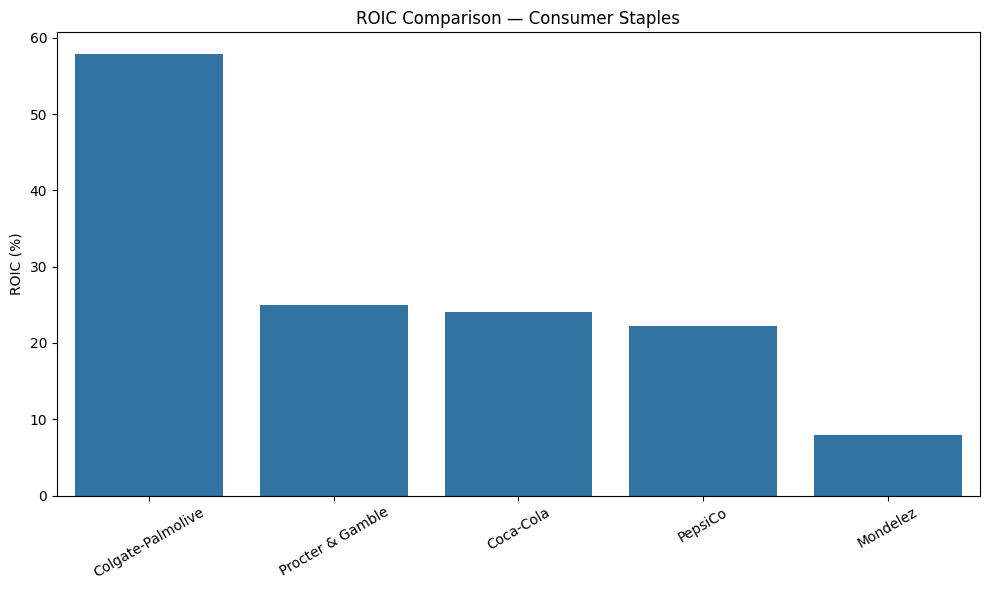

In [ ]:
# ============================================
# ROIC COMPARISON
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=latest.sort_values("ROIC", ascending=False),
    x="Company",
    y="ROIC"
)

plt.title("ROIC Comparison — Consumer Staples")
plt.ylabel("ROIC (%)")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

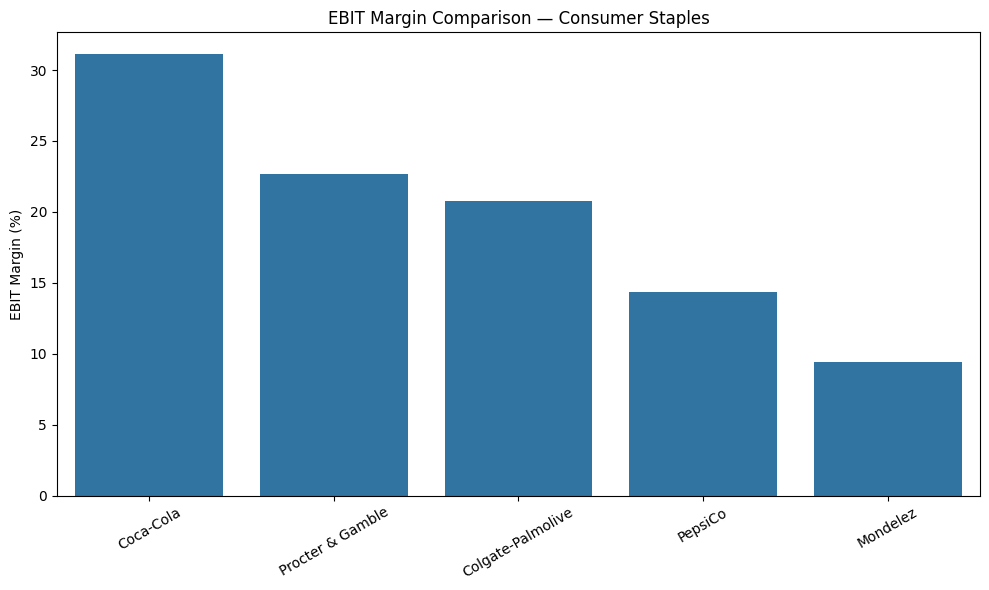

In [ ]:
# ============================================
# EBIT MARGIN COMPARISON
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=latest.sort_values("EBIT_Margin", ascending=False),
    x="Company",
    y="EBIT_Margin"
)

plt.title("EBIT Margin Comparison — Consumer Staples")
plt.ylabel("EBIT Margin (%)")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 5. Leverage & Financial Risk

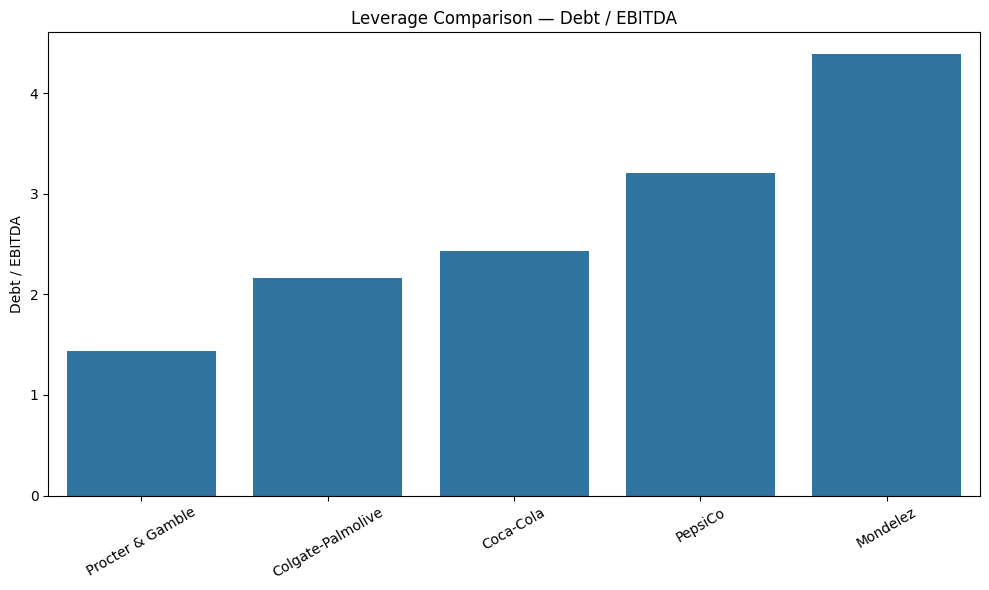

In [ ]:
# ============================================
# DEBT / EBITDA COMPARISON
# ============================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=latest.sort_values("Debt_to_EBITDA"),
    x="Company",
    y="Debt_to_EBITDA"
)

plt.title("Leverage Comparison — Debt / EBITDA")
plt.ylabel("Debt / EBITDA")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# SAVE DATASETS
# ============================================

df.to_csv("consumer_staples_full_dataset.csv", index=False)

peer_comparison.to_csv(
    "consumer_staples_peer_comparison.csv",
    index=False
)

ranked.to_csv(
    "consumer_staples_rankings.csv",
    index=False
)

print("All datasets saved successfully.")

All datasets saved successfully.


In [ ]:
# ============================================
# CURRENT MARKET DATA
# ============================================

valuation_rows = []

for company, ticker in companies.items():

    stock = yf.Ticker(ticker)
    info = stock.info

    # Latest share price
    hist = stock.history(period="5d")
    share_price = hist["Close"].dropna().iloc[-1]

    market_cap = info.get("marketCap", np.nan)
    enterprise_value = info.get("enterpriseValue", np.nan)

    valuation_rows.append({
        "Company": company,
        "Ticker": ticker,
        "Share_Price": share_price,
        "Market_Cap": market_cap,
        "Enterprise_Value": enterprise_value
    })

valuation = pd.DataFrame(valuation_rows)

valuation

,Company,Ticker,Share_Price,Market_Cap,Enterprise_Value
0,Procter & Gamble,PG,146.440002,340132134912,366458961920
1,Coca-Cola,KO,88.070000,378925481984,408980520960
2,PepsiCo,PEP,137.630005,188002582528,230520029184
3,Colgate-Palmolive,CL,88.769997,70765027328,77499031552
4,Mondelez,MDLZ,61.279999,78212161536,98608160768


In [ ]:
# ============================================
# MERGE VALUATION + FUNDAMENTALS
# ============================================

valuation = valuation.merge(
    latest[
        [
            "Company",
            "Revenue",
            "EBITDA",
            "Net_Income",
            "FCF",
            "ROIC",
            "Revenue_Growth"
        ]
    ],
    on="Company",
    how="left"
)

valuation

,Company,Ticker,Share_Price,Market_Cap,Enterprise_Value,Revenue,EBITDA,Net_Income,FCF,ROIC,Revenue_Growth
0,Procter & Gamble,PG,146.440002,340132134912,366458961920,8.703200e+10,2.441400e+10,1.604600e+10,1.514700e+10,24.945367,3.260405
1,Coca-Cola,KO,88.070000,378925481984,408980520960,4.794100e+10,1.870200e+10,1.310700e+10,5.296000e+09,24.106378,1.869914
2,PepsiCo,PEP,137.630005,188002582528,230520029184,9.392500e+10,1.554300e+10,8.240000e+09,7.672000e+09,22.197542,2.254665
3,Colgate-Palmolive,CL,88.769997,70765027328,77499031552,2.038200e+10,3.956000e+09,2.132000e+09,3.634000e+09,57.827869,1.397940
4,Mondelez,MDLZ,61.279999,78212161536,98608160768,3.853700e+10,4.971000e+09,2.451000e+09,3.235000e+09,7.953072,5.751763


In [ ]:
# ============================================
# VALUATION MULTIPLES
# ============================================

valuation["P_E"] = (
    valuation["Market_Cap"] / valuation["Net_Income"]
)

valuation["EV_EBITDA"] = (
    valuation["Enterprise_Value"] / valuation["EBITDA"]
)

valuation["P_S"] = (
    valuation["Market_Cap"] / valuation["Revenue"]
)

valuation["FCF_Yield"] = (
    valuation["FCF"] / valuation["Market_Cap"] * 100
)

valuation["Earnings_Yield"] = (
    valuation["Net_Income"] / valuation["Market_Cap"] * 100
)

valuation[
    [
        "Company",
        "P_E",
        "EV_EBITDA",
        "P_S",
        "FCF_Yield",
        "Earnings_Yield"
    ]
].round(2)

,Company,P_E,EV_EBITDA,P_S,FCF_Yield,Earnings_Yield
0,Procter & Gamble,21.20,15.01,3.91,4.45,4.72
1,Coca-Cola,28.91,21.87,7.90,1.40,3.46
2,PepsiCo,22.82,14.83,2.00,4.08,4.38
3,Colgate-Palmolive,33.19,19.59,3.47,5.14,3.01
4,Mondelez,31.91,19.84,2.03,4.14,3.13


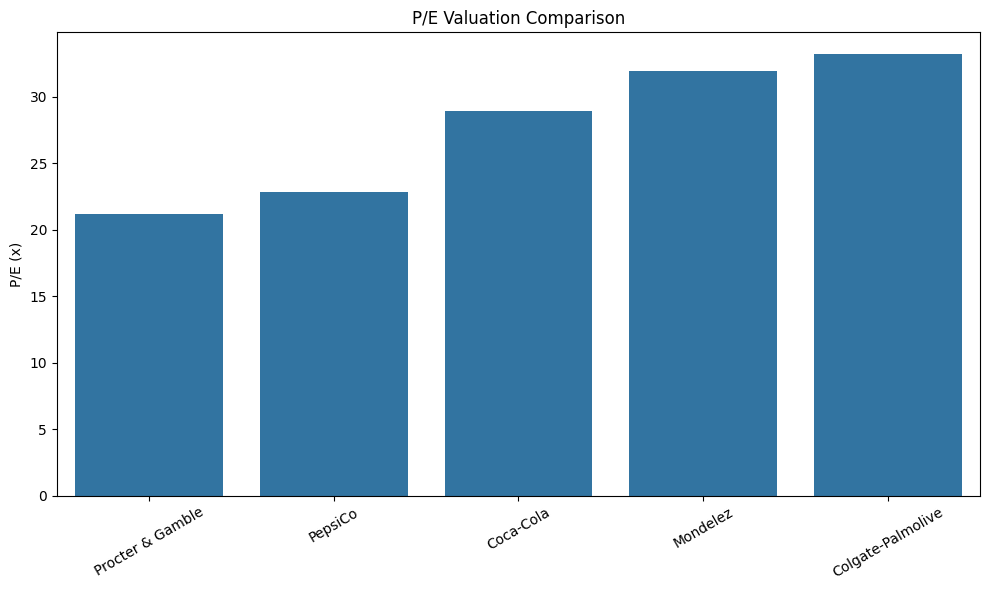

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=valuation.sort_values("P_E"),
    x="Company",
    y="P_E"
)

plt.title("P/E Valuation Comparison")
plt.ylabel("P/E (x)")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

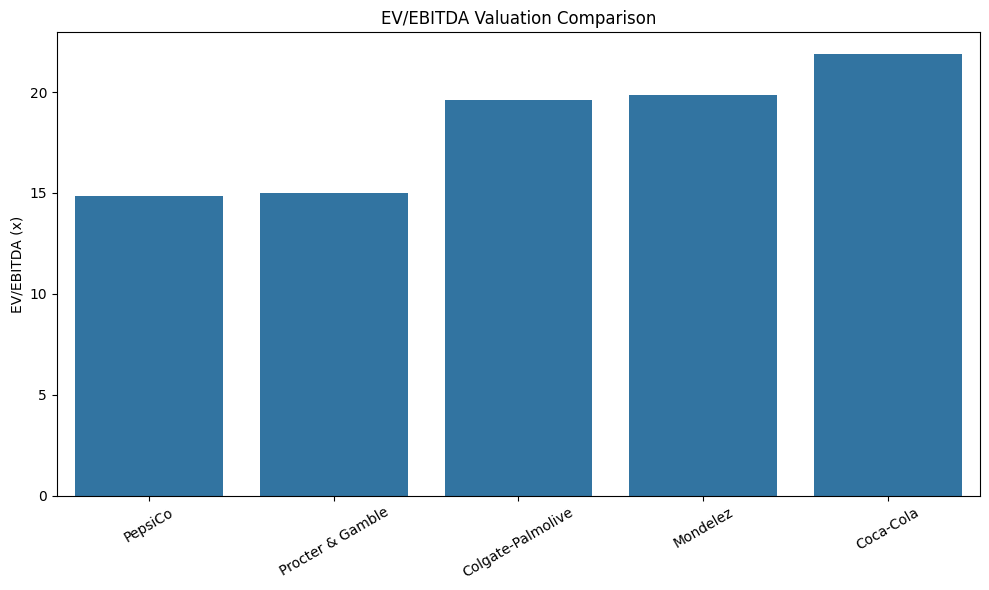

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=valuation.sort_values("EV_EBITDA"),
    x="Company",
    y="EV_EBITDA"
)

plt.title("EV/EBITDA Valuation Comparison")
plt.ylabel("EV/EBITDA (x)")
plt.xlabel("")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

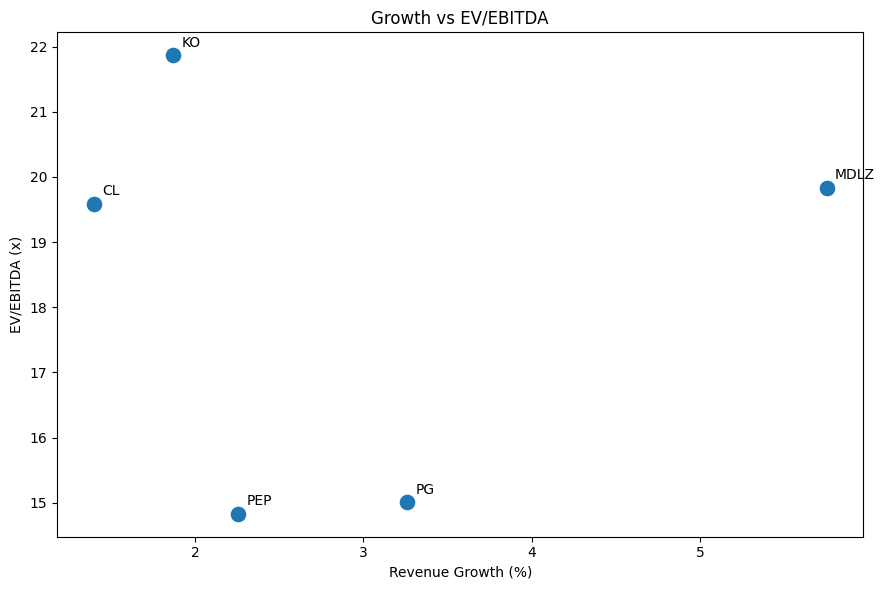

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=valuation,
    x="Revenue_Growth",
    y="EV_EBITDA",
    s=150
)

for _, row in valuation.iterrows():
    plt.annotate(
        row["Ticker"],
        (row["Revenue_Growth"], row["EV_EBITDA"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.title("Growth vs EV/EBITDA")
plt.xlabel("Revenue Growth (%)")
plt.ylabel("EV/EBITDA (x)")
plt.tight_layout()
plt.show()

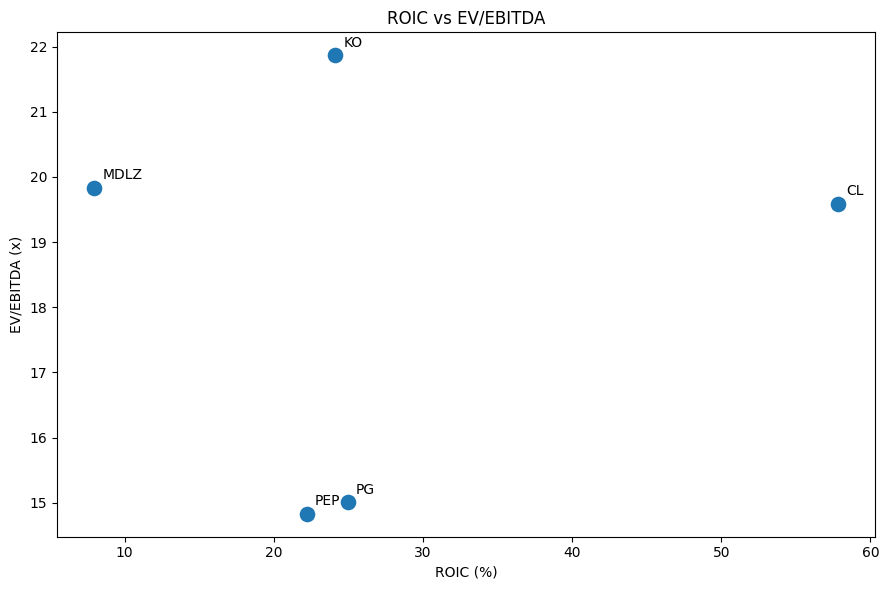

In [ ]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=valuation,
    x="ROIC",
    y="EV_EBITDA",
    s=150
)

for _, row in valuation.iterrows():
    plt.annotate(
        row["Ticker"],
        (row["ROIC"], row["EV_EBITDA"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.title("ROIC vs EV/EBITDA")
plt.xlabel("ROIC (%)")
plt.ylabel("EV/EBITDA (x)")
plt.tight_layout()
plt.show()

In [ ]:
valuation.to_csv(
    "consumer_staples_valuation_analysis.csv",
    index=False
)

print("Valuation analysis saved.")

Valuation analysis saved.


In [ ]:
valuation[
    [
        "Company",
        "Revenue_Growth",
        "ROIC",
        "P_E",
        "EV_EBITDA",
        "P_S",
        "FCF_Yield"
    ]
].round(2)

,Company,Revenue_Growth,ROIC,P_E,EV_EBITDA,P_S,FCF_Yield
0,Procter & Gamble,3.26,24.95,21.20,15.01,3.91,4.45
1,Coca-Cola,1.87,24.11,28.91,21.87,7.90,1.40
2,PepsiCo,2.25,22.20,22.82,14.83,2.00,4.08
3,Colgate-Palmolive,1.40,57.83,33.19,19.59,3.47,5.14
4,Mondelez,5.75,7.95,31.91,19.84,2.03,4.14


## 6. Financial Quality Ranking

In [ ]:
# ============================================
# FINAL FY2025 FINANCIAL SCORE
# ============================================

score_metrics = {
    "Revenue_Growth": True,
    "EBIT_Margin": True,
    "ROIC": True,
    "FCF_Margin": True,
    "Asset_Turnover": True,
    "Interest_Coverage": True,
    "Debt_to_EBITDA": False
}

score_2025 = analysis_2025[["Company", "Ticker"]].copy()

for metric, higher_is_better in score_metrics.items():
    score_2025[metric + "_Rank"] = (
        analysis_2025[metric]
        .rank(
            ascending=not higher_is_better,
            method="min"
        )
    )

score_2025["Average_Rank"] = score_2025.iloc[:, 2:].mean(axis=1)

score_2025["Overall_Rank"] = (
    score_2025["Average_Rank"]
    .rank(method="min")
    .astype(int)
)

score_2025 = score_2025.sort_values("Overall_Rank")

score_2025

,Company,Ticker,Revenue_Growth_Rank,EBIT_Margin_Rank,ROIC_Rank,FCF_Margin_Rank,Asset_Turnover_Rank,Interest_Coverage_Rank,Debt_to_EBITDA_Rank,Average_Rank,Overall_Rank
14,Colgate-Palmolive,CL,4.0,3.0,1.0,1.0,1.0,2.0,2.0,2.000000,1
1,Procter & Gamble,PG,5.0,2.0,2.0,2.0,3.0,1.0,1.0,2.285714,2
4,Coca-Cola,KO,3.0,1.0,3.0,3.0,5.0,4.0,3.0,3.142857,3
9,PepsiCo,PEP,2.0,4.0,4.0,5.0,2.0,3.0,4.0,3.428571,4
19,Mondelez,MDLZ,1.0,5.0,5.0,4.0,4.0,5.0,5.0,4.142857,5


In [ ]:
# ============================================
# CLEAN SCORECARD
# ============================================

scorecard = latest[
    [
        "Company",
        "Ticker",
        "Revenue_Growth",
        "EBIT_Margin",
        "ROIC",
        "ROE",
        "FCF_Margin",
        "Asset_Turnover",
        "Interest_Coverage",
        "Debt_to_EBITDA",
        "Debt_to_Equity"
    ]
].copy()

scorecard = scorecard.merge(
    score[["Company", "Overall_Rank"]],
    on="Company"
)

scorecard = scorecard.sort_values("Overall_Rank")

scorecard.round(2)

,Company,Ticker,Revenue_Growth,EBIT_Margin,ROIC,ROE,FCF_Margin,Asset_Turnover,Interest_Coverage,Debt_to_EBITDA,Debt_to_Equity,Overall_Rank
4,Procter & Gamble,PG,3.26,22.69,24.95,29.67,17.40,0.69,22.52,1.43,0.65,1
1,Colgate-Palmolive,CL,1.40,20.77,57.83,3948.15,17.83,1.25,15.85,2.16,158.41,2
0,Coca-Cola,KO,1.87,31.10,24.11,40.74,11.05,0.46,9.02,2.43,1.41,3
3,PepsiCo,PEP,2.25,14.36,22.20,40.38,8.17,0.87,12.03,3.21,2.45,4
2,Mondelez,MDLZ,5.75,9.39,7.95,9.49,8.39,0.54,6.04,4.39,0.84,5


In [ ]:
scorecard.to_csv(
    "consumer_staples_final_scorecard.csv",
    index=False
)

print("Final scorecard saved.")

Final scorecard saved.


In [ ]:
# ============================================
# FINAL FY2025 FINANCIAL SCORE
# ============================================

score_metrics = {
    "Revenue_Growth": True,
    "EBIT_Margin": True,
    "ROIC": True,
    "ROE": True,
    "FCF_Margin": True,
    "Asset_Turnover": True,
    "Interest_Coverage": True,
    "Debt_to_EBITDA": False,
    "Debt_to_Equity": False
}

score_2025 = analysis_2025[["Company", "Ticker"]].copy()

for metric, higher_is_better in score_metrics.items():
    score_2025[metric + "_Rank"] = (
        analysis_2025[metric]
        .rank(
            ascending=not higher_is_better,
            method="min"
        )
    )

score_2025["Average_Rank"] = score_2025.iloc[:, 2:].mean(axis=1)

score_2025["Overall_Rank"] = (
    score_2025["Average_Rank"]
    .rank(method="min")
    .astype(int)
)

score_2025 = score_2025.sort_values("Overall_Rank")

score_2025

print("Valuation data as of:", hist.index[-1].date())

Valuation data as of: 2026-09-04


In [ ]:
# ============================================
# FINAL FY2025 FINANCIAL SCORE
# ============================================

score_metrics = {
    "Revenue_Growth": True,
    "EBIT_Margin": True,
    "ROIC": True,
    "FCF_Margin": True,
    "Asset_Turnover": True,
    "Interest_Coverage": True,
    "Debt_to_EBITDA": False
}

score_2025 = analysis_2025[["Company", "Ticker"]].copy()

for metric, higher_is_better in score_metrics.items():
    score_2025[metric + "_Rank"] = (
        analysis_2025[metric]
        .rank(
            ascending=not higher_is_better,
            method="min"
        )
    )

score_2025["Average_Rank"] = score_2025.iloc[:, 2:].mean(axis=1)

score_2025["Overall_Rank"] = (
    score_2025["Average_Rank"]
    .rank(method="min")
    .astype(int)
)

score_2025 = score_2025.sort_values("Overall_Rank")

score_2025

,Company,Ticker,Revenue_Growth_Rank,EBIT_Margin_Rank,ROIC_Rank,FCF_Margin_Rank,Asset_Turnover_Rank,Interest_Coverage_Rank,Debt_to_EBITDA_Rank,Average_Rank,Overall_Rank
14,Colgate-Palmolive,CL,4.0,3.0,1.0,1.0,1.0,2.0,2.0,2.000000,1
1,Procter & Gamble,PG,5.0,2.0,2.0,2.0,3.0,1.0,1.0,2.285714,2
4,Coca-Cola,KO,3.0,1.0,3.0,3.0,5.0,4.0,3.0,3.142857,3
9,PepsiCo,PEP,2.0,4.0,4.0,5.0,2.0,3.0,4.0,3.428571,4
19,Mondelez,MDLZ,1.0,5.0,5.0,4.0,4.0,5.0,5.0,4.142857,5


In [ ]:
from google.colab import files

files.download("FINAL_Consumer_Staples_Scorecard.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# VALUATION DATA
# ============================================

valuation_rows = []

for company, ticker in companies.items():
    stock = yf.Ticker(ticker)

    info = stock.info

    # Latest market price
    hist = stock.history(period="5d")
    share_price = hist["Close"].dropna().iloc[-1]

    market_cap = info.get("marketCap", np.nan)
    enterprise_value = info.get("enterpriseValue", np.nan)

    valuation_rows.append({
        "Company": company,
        "Ticker": ticker,
        "Share_Price": share_price,
        "Market_Cap": market_cap,
        "Enterprise_Value": enterprise_value
    })

valuation = pd.DataFrame(valuation_rows)

valuation

,Company,Ticker,Share_Price,Market_Cap,Enterprise_Value
0,Procter & Gamble,PG,146.440002,340132134912,366458961920
1,Coca-Cola,KO,88.070000,378925481984,408980520960
2,PepsiCo,PEP,137.630005,188002582528,230520029184
3,Colgate-Palmolive,CL,88.769997,70765027328,77499031552
4,Mondelez,MDLZ,61.279999,78212161536,98608160768


## 7. Relative Valuation

In [ ]:
# ============================================
# MERGE WITH FY2025 FUNDAMENTALS
# ============================================

valuation = valuation.merge(
    analysis_2025[
        [
            "Company",
            "Revenue",
            "EBITDA",
            "Net_Income",
            "FCF",
            "ROIC",
            "Revenue_Growth"
        ]
    ],
    on="Company",
    how="left"
)

# Calculate valuation multiples
valuation["P_E"] = (
    valuation["Market_Cap"] / valuation["Net_Income"]
)

valuation["EV_EBITDA"] = (
    valuation["Enterprise_Value"] / valuation["EBITDA"]
)

valuation["P_S"] = (
    valuation["Market_Cap"] / valuation["Revenue"]
)

valuation["FCF_Yield"] = (
    valuation["FCF"] / valuation["Market_Cap"] * 100
)

valuation[
    [
        "Company",
        "Ticker",
        "Revenue_Growth",
        "ROIC",
        "P_E",
        "EV_EBITDA",
        "P_S",
        "FCF_Yield"
    ]
].round(2)

,Company,Ticker,Revenue_Growth,ROIC,P_E,EV_EBITDA,P_S,FCF_Yield
0,Procter & Gamble,PG,0.29,26.25,21.29,15.32,4.04,4.13
1,Coca-Cola,KO,1.87,24.11,28.91,21.87,7.90,1.40
2,PepsiCo,PEP,2.25,22.20,22.82,14.83,2.00,4.08
3,Colgate-Palmolive,CL,1.40,57.83,33.19,19.59,3.47,5.14
4,Mondelez,MDLZ,5.75,7.95,31.91,19.84,2.03,4.14


In [ ]:
valuation[
    [
        "Company",
        "Ticker",
        "Revenue_Growth",
        "ROIC",
        "P_E",
        "EV_EBITDA",
        "P_S",
        "FCF_Yield"
    ]
].to_csv(
    "FINAL_Consumer_Staples_Valuation.csv",
    index=False
)

print("Valuation file saved.")

Valuation file saved.


In [ ]:
from google.colab import files

files.download("FINAL_Consumer_Staples_Valuation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8. Key Analyst Takeaways

- Colgate-Palmolive ranks highest on overall financial quality, supported by strong ROIC, margins, and capital efficiency.
- Procter & Gamble combines strong profitability with relatively low leverage and high interest coverage.
- Coca-Cola generates the strongest EBIT and net margins but trades at a premium valuation.
- PepsiCo offers the lowest EV/EBITDA multiple among the peer group but carries higher leverage.
- Mondelez has the strongest revenue growth but comparatively lower ROIC and weaker profitability.